In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import importlib_resources
from dtuimldmtools import rlr_validate, draw_neural_net, train_neural_net
from sklearn import model_selection, linear_model as lm
from scipy.linalg import svd
from scipy.io import loadmat
from scipy import stats

save_dir = 'plots'
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Open and filter data

In [67]:
# Read the data
df = pd.read_csv(
    '../dataset/auto-mpg.data',
    sep=r'\s+',
    names=[
        "mpg", "cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year", "origin", "car_name"
    ],
    na_values=['?']  # Converts only '?' to NaN
).dropna()

# from https://github.com/Munees11/Auto-MPG-prediction/blob/master/Scripts/Auto%20MPG%20Predictions.ipynb
# df['brand'] = df["car_name"].str.extract('(^.*?)\s')
# df["origin"] = df["origin"].apply(lambda x: "USA" if x == 1 else ("Europe" if x == 2 else "Japan"))

# Drop the non-continuous columns
continous_columns = [col for col in df.columns if col not in ['model_year', 'origin', 'car_name']]
df_continous = df[continous_columns].copy()

# Drop the non-numerical columns
numerical_columns = [col for col in df.columns if col not in ['car_name']]
df_numerical = df[numerical_columns].copy()

# Make the cylinders attribute as continuous
df_continous['cylinders'] = (df_continous['cylinders'] - df_continous['cylinders'].min()) / (df_continous['cylinders'].max() - df_continous['cylinders'].min())
df_numerical['cylinders'] = (df_numerical['cylinders'] - df_numerical['cylinders'].min()) / (df_numerical['cylinders'].max() - df_numerical['cylinders'].min())

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


# Regression part A

Introduce a regularization parameter λ as discussed in chapter 14 of the lecture notes, and
estimate the generalization error for different values of λ. Specifically, choose a reasonable
range of values of λ (ideally one where the generalization error first drop and then in-
creases), and for each value use K = 10 fold cross-validation (algorithm 5) to estimate the
generalization error. Include a figure of the estimated generalization error as a function of
λ in the report and briefly discuss the result

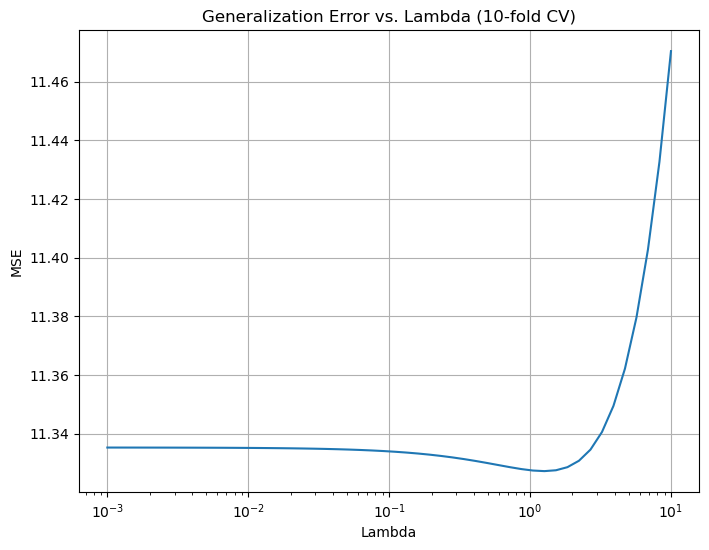

MPG regression function for optimal lambda (1.265): y =
        23.45 +       (bias)
     -0.77 x1 +       (cylinders)
      1.78 x2 +       (displacement)
     -0.69 x3 +       (horsepower)
     -5.26 x4 +       (weight)
      0.18 x5 +       (acceleration)
      2.74 x6 +       (model_year)
      1.13 x7 +       (origin)


In [68]:
# Convert DataFrame to a NumPy array
data_matrix = df_numerical.to_numpy()
attributeNames = df_numerical.columns

X = data_matrix[:, 1:]
y = data_matrix[:, 0]

# Add offset
X = np.concatenate((np.ones((X.shape[0], 1)), X), 1)
attributeNames = ["bias"] + list(attributeNames[1:])

lambdas = np.logspace(-3, 1, 50)

# Set up 10-fold cross-validation
K = 10
CV = model_selection.KFold(K, shuffle=True)

# Initialize arrays to store parameters
test_errors = np.zeros((K, len(lambdas)))
w_matrix = np.zeros((K, X.shape[1], len(lambdas)))

# Outer loop for K-fold cross-validation
k = 0
for train_index, test_index in CV.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Standardize data based on training set
    mu = np.mean(X_train[:, 1:], 0)
    sigma = np.std(X_train[:, 1:], 0)
    X_train[:, 1:] = (X_train[:, 1:] - mu) / sigma
    X_test[:, 1:] = (X_test[:, 1:] - mu) / sigma

    # Inner loop to evaluate different lambda values
    for i, lambda_val in enumerate(lambdas):
        # Calculate weights using linear algebra
        N, M = X_train.shape
        Xty = X_train.T @ y_train
        XtX = X_train.T @ X_train
        lambdaI = lambda_val * np.eye(M)
        lambdaI[0, 0] = 0  # Do not regularize the bias term
        w = np.linalg.solve(XtX + lambdaI, Xty)
        w_matrix[k, :, i] = w

        # Predict on the test set and calculate error
        y_pred = X_test @ w
        test_errors[k, i] = np.mean((y_test - y_pred)**2)
    k += 1

# Calculate the average test error for each lambda value across all folds
mean_test_errors = np.mean(test_errors, axis=0)

# Find the optimal lambda value (minimum generalization error)
optimal_lambda_idx = np.argmin(mean_test_errors)

# Find the corresponding weights to the optimal lambda
weights_per_optimal_lambda = w_matrix[:, :, optimal_lambda_idx]
mean_weights = np.mean(weights_per_optimal_lambda, axis=0)

# Plot the generalization error (average test error) against lambda values
plt.figure(figsize=(8, 6))
plt.plot(lambdas, mean_test_errors)
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Generalization Error vs. Lambda (10-fold CV)')
plt.grid(True)
plt.show()

print(f"MPG regression function for optimal lambda ({lambdas[optimal_lambda_idx]:.3f}): y =")
for i, weight in enumerate(mean_weights):
  if i == 0:
    print(f"{weight:>13.2f} + {'':>5} ({attributeNames[i]})")
  else:
    print(f"{weight:>10.2f} x{i} + {'':>5} ({attributeNames[i]})")


# Regression part B

Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use 2-level cross-validation to compare the models with K1 = K2 = 10 folds2. As a baseline model, we will apply a linear regression model with no features, i.e. it computes the mean of y on the training data, and use this value to predict y on the test data. Make sure you can fit an ANN model to the data. As complexity-controlling parameter for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select a reasonable range of values for h (which should include h = 1), and describe the range of values you will use for h and λ.

---

Statistically evaluate if there is a significant performance difference between the fitted ANN, linear regression model and baseline using the methods described in chapter 11.
These comparisons will be made pairwise (ANN vs. linear regression; ANN vs. base-line; linear regression vs. baseline). We will allow some freedom in what test to choose.

Therefore, choose either:
*setup I* (section 11.3): Use the paired t-test described in Box 11.3.4
setup II (section 11.4): Use the method described in Box 11.4.1

Include p-values and confidence intervals for the three pairwise tests in your report and conclude on the results: Is one model better than the other? Are the two models better than the baseline? Are some of the models identical? What recommendations would you make based on what you’ve learned?

In [69]:
# input must be ndarrays!
def ann_validate(X, y, hidden_units, internal_K, max_iter=10000, n_replicates=1):
    CV_internal = model_selection.KFold(internal_K, shuffle=True)
    loss_fn = torch.nn.MSELoss()
    
    best_h = None
    best_mse = float("inf")
    
    for h in hidden_units:
        se = []
        for k, (train_index, test_index) in enumerate(CV_internal.split(X, y)):
            X_train, y_train = torch.Tensor(X[train_index]), torch.Tensor(y[train_index])
            X_test, y_test = torch.Tensor(X[test_index]), torch.Tensor(y[test_index])

            model = lambda: torch.nn.Sequential(
                torch.nn.Linear(X_train.shape[1], h),
                torch.nn.Tanh(),
                torch.nn.Linear(h, 1)
            )
            
            net, _, _ = train_neural_net(
                model, 
                loss_fn, 
                X=X_train, 
                y=y_train, 
                n_replicates=n_replicates, 
                max_iter=max_iter
            )
            
            y_test_est = net(X_test).detach()
            se.append((y_test_est.float() - y_test.float()) ** 2)  # squared error
        
        mse = np.mean(np.concatenate(se))
        print(f"\n\nMSE error for ANN with h = {h} units after cv ==> {mse}")
        if mse < best_mse:
            best_mse = mse
            best_h = h
            
    return best_h, best_mse


	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	480.67682	0.0001956341
		2000	398.6783	0.00018321964
		3000	331.54877	0.00018654147
		Final loss:
		3000	331.54877	0.00018654147

	Replicate: 1/1
		Iter	Loss			Rel. loss


/opt/homebrew/Caskroom/miniconda/base/envs/dtu02450/lib/python3.11/site-packages/dtuimldmtools/models/nn_trainer.py:141: RuntimeWarning: overflow encountered in cast
  if loss_value < best_final_loss:


		1000	489.61996	0.00026165147
		2000	394.21478	0.00019705614
		3000	324.99667	0.00019189723
		Final loss:
		3000	324.99667	0.00019189723

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	519.55035	0.0001802945
		2000	412.1217	0.00019130838
		3000	341.60736	0.00018694373
		Final loss:
		3000	341.60736	0.00018694373

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	526.6017	0.00016084865
		2000	403.87424	0.00021251096
		3000	330.9568	0.0001930508
		Final loss:
		3000	330.9568	0.0001930508

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	530.74744	0.00021431125
		2000	434.79904	0.00018736625
		3000	361.59784	0.00018386608
		Final loss:
		3000	361.59784	0.00018386608

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	543.16736	0.00022873089
		2000	448.38846	0.00017971569
		3000	375.00375	0.00017949071
		Final loss:
		3000	375.00375	0.00017949071

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	504.62924	0.0001971709
		2000	418.3019	0.00018279399
		3000	348.39124	0.00018417985
		Final loss:
		3000	

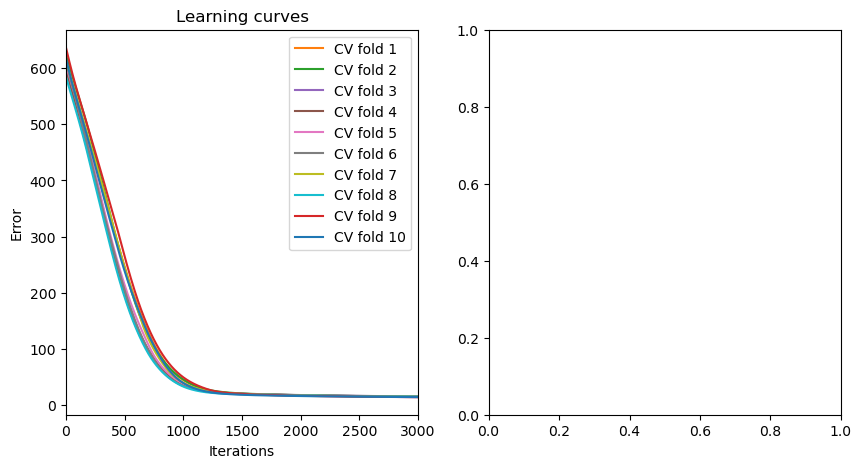

In [70]:
X = df_continous.values[:, 1:]  # features
X = np.concatenate((np.ones((X.shape[0], 1)), X), 1) # bias for regularized linear regression
attributeNames = ["bias"] + list(df_continous.columns[1:])
y = df_continous.values[:, 0]  # target
N, M = X.shape

# Range of hyperparameters
lambdas = np.logspace(-3, 1, 50)
hidden_units = np.linspace(1, 25, 5, dtype=int)

# Parameters for ANN training
max_iter = 3000
loss_fn = torch.nn.MSELoss()

# Create cross-validation partitions for evaluation
# ************
# TODO MUST BE 10x10: IF LESS IS FOR CODE TESTING ONLY
# ************
K = 10
K_internal = 10
CV = model_selection.KFold(K, shuffle=True)

# Initialize variables
w_lr = np.zeros((M, K))
Error_train_lr = np.zeros((K, 1))
Error_test_lr = np.zeros((K, 1))

w_rlr = np.zeros((M, K))
Error_train_rlr = np.zeros((K, 1))
Error_test_rlr = np.zeros((K, 1))

w_noreg = np.zeros((M, K))
Error_train_nofeatures = np.zeros((K, 1))
Error_test_nofeatures = np.zeros((K, 1))

# w_ann = np.zeros((M, K))
Error_train_ann = np.zeros((K, 1))
Error_test_ann = np.zeros((K, 1))

fold_results = []
test_vs_predictions = [[] for _ in range(4)]    # y.shape[0] x 4 (expected y, baseline, rlr, ann)

# Setup figure for display of learning curves and error rates in fold
summaries, summaries_axes = plt.subplots(1, 2, figsize=(10, 5))
color_list = [
    "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink",
    "tab:gray", "tab:olive", "tab:cyan", "tab:red", "tab:blue"
]

for k, (train_index, test_index) in enumerate(CV.split(X, y)):
    # Extract training and test set for current CV fold
    X_train, y_train = X[train_index], y[train_index]
    X_test, y_test = X[test_index], y[test_index]
    # Save expected y values
    test_vs_predictions[0].extend(y_test)
    
    # Regularized linear regression
    opt_val_err, opt_lambda, mean_w_vs_lambda, train_err_vs_lambda, test_err_vs_lambda = rlr_validate(X_train, y_train, lambdas, K_internal)

    # Standardize outer fold based on training set
    X_train[:, 1:] = (X_train[:, 1:] - X_train[:, 1:].mean(0)) / X_train[:, 1:].std(0)
    X_test[:, 1:] = (X_test[:, 1:] - X_test[:, 1:].mean(0)) / X_test[:, 1:].std(0)

    # Compute mean squared error without features
    Error_train_nofeatures[k] = np.mean(np.square(y_train - y_train.mean()))
    Error_test_nofeatures[k] = np.mean(np.square(y_test - y_test.mean()))
    # Save estimated y values for no features
    test_vs_predictions[1].extend(y_test.mean() * np.ones(y_test.shape[0]))
    
    # Estimate weights and errors with regularization
    Xty, XtX = X_train.T @ y_train, X_train.T @ X_train
    lambdaI = opt_lambda * np.eye(M)
    lambdaI[0, 0] = 0 # Do not regularize the bias term
    
    w_rlr[:, k] = np.linalg.solve(XtX + lambdaI, Xty).squeeze()
    Error_train_rlr[k] = np.mean(np.square(y_train - X_train @ w_rlr[:, k]))
    Error_test_rlr[k] = np.mean(np.square(y_test - X_test @ w_rlr[:, k]))
    # Save estimated y values for regularized linear regression
    test_vs_predictions[2].extend(X_test @ w_rlr[:, k])

    # Estimate weights and errors without regularization
    w_noreg[:, k] = np.linalg.solve(XtX, Xty).squeeze()
    Error_train_lr[k] = np.mean(np.square(y_train - X_train @ w_noreg[:, k]))
    Error_test_lr[k] = np.mean(np.square(y_test - X_test @ w_noreg[:, k]))

    # ANN training: find best H (number of hidden units) using internal CV
    best_h, best_mse = ann_validate(X_train[:, 1:], y_train.reshape(-1, 1), hidden_units, K_internal, max_iter)

    # Train final ANN with best H
    model = lambda: torch.nn.Sequential(
        torch.nn.Linear(M - 1, best_h),
        torch.nn.Tanh(),
        torch.nn.Linear(best_h, 1)
    )

    # Map to torch tensors (requires Y to be column vector!)
    X_train, y_train, X_test, y_test = map(torch.Tensor, (X_train[:, 1:], y_train.reshape(-1, 1), X_test[:, 1:], y_test.reshape(-1, 1)))

    net, final_loss, learning_curve = train_neural_net(
        model, 
        loss_fn, 
        X=X_train, 
        y=y_train, 
        n_replicates=3, 
        max_iter=max_iter
    )

    print(f"\n\nMSE for ANN with best h = {best_h} units on CV fold no. {k+1}/{K} ==> {final_loss}")
        
    # Estimate weights and errors for ANN
    y_train_est = net(X_train).detach()
    y_test_est = net(X_test).detach()
    Error_train_ann[k] = np.mean(np.square((y_train_est.float() - y_train.float()).numpy()))
    Error_test_ann[k] = np.mean(np.square((y_test_est.float() - y_test.float()).numpy()))
    # Save estimated y values for ANN
    test_vs_predictions[3].extend(y_test_est.float().numpy().squeeze())

    fold_results.append({
        "Fold": k + 1,
        "Best Lambda": opt_lambda,
        "Best H": best_h,
        "Test Error (Best Lambda)": Error_test_rlr[k, 0],
        "Test Error (Best H)": Error_test_ann[k, 0],
        "Test Error (Baseline)": Error_test_nofeatures[k, 0]
    })

    # Display the learning curve for the best net in the current fold
    (h,) = summaries_axes[0].plot(learning_curve, label=f"CV fold {k + 1}", color=color_list[k])
    h.set_label(f"CV fold {k + 1}")
    summaries_axes[0].set_xlabel("Iterations")
    summaries_axes[0].set_xlim((0, max_iter))
    summaries_axes[0].legend(loc="best")
    summaries_axes[0].set_ylabel("Error")
    summaries_axes[0].grid(axis='y')
    summaries_axes[0].set_title("Learning curves")

# -------------------------------
# ANN validation
# -------------------------------

# ANN test error in each fold
# summaries_axes[1].bar(np.arange(1, K + 1), np.squeeze(Error_test_ann), color=color_list)
# summaries_axes[1].set_xlabel("Fold")
# summaries_axes[1].set_xticks(np.arange(1, K + 1))
# summaries_axes[1].set_ylabel("MSE")
# summaries_axes[1].set_title("Test mean-squared-error")
# plt.show()

# ANN drawing from the last fold
# print("Diagram of best neural net from the last fold:")
# weights = [net[i].weight.data.numpy().T for i in [0, 2]]
# biases = [net[i].bias.data.numpy() for i in [0, 2]]
# tf = [str(net[i]) for i in [1, 2]]
# draw_neural_net(weights, biases, tf, attribute_names=attributeNames[1:])

print(f"\nEstimated generalization error, RMSE: {round(np.sqrt(np.mean(Error_test_ann)), 4)}")

# -------------------------------
# Model statistics
# -------------------------------

# MSE for each model
print("Baseline (no features):")
print(f"- Training error: {Error_train_nofeatures.mean()}")
print(f"- Test error: {Error_test_nofeatures.mean()}\n")
print("Linear regression without feature selection (regularization):")
print(f"- Training error: {Error_train_lr.mean()}")
print(f"- Test error: {Error_test_lr.mean()}\n")
print("Regularized linear regression:")
print(f"- Training error: {Error_train_rlr.mean()}")
print(f"- Test error: {Error_test_rlr.mean()}\n")
print("Artificial Neural Network:")
print(f"- Training error: {Error_train_ann.mean()}")
print(f"- Test error: {Error_test_ann.mean()}\n")

# The same but in a table
results_df = pd.DataFrame(fold_results)
results_df = results_df.set_index("Fold")
print(results_df)

# -------------------------------
# T-test for comparing the models
# -------------------------------

test_vs_predictions = np.array([np.array(predictions) for predictions in test_vs_predictions])

# Compute mean squared error for baseline
z_baseline = np.abs(test_vs_predictions[0] - test_vs_predictions[1]) ** 2
z_best_rlr = np.abs(test_vs_predictions[0] - test_vs_predictions[2]) ** 2
z_best_ann = np.abs(test_vs_predictions[0] - test_vs_predictions[3]) ** 2

# Perform statistical comparison of the models
alpha = 0.05

# Confidence intervals of all models
CI_baseline = stats.t.interval(
    1 - alpha, df=len(z_baseline) - 1, loc=np.mean(z_baseline), scale=stats.sem(z_baseline)
)  
CI_best_ann = stats.t.interval(
    1 - alpha, df=len(z_best_ann) - 1, loc=np.mean(z_best_ann), scale=stats.sem(z_best_ann)
)
CI_best_rlr = stats.t.interval(
    1 - alpha, df=len(z_best_rlr) - 1, loc=np.mean(z_best_rlr), scale=stats.sem(z_best_rlr)
)

# Confidence intervals and p-values for comparisons
z_best_ann_vs_baseline = z_best_ann - z_baseline
z_best_rlr_vs_baseline = z_best_rlr - z_baseline
z_best_ann_vs_rlr = z_best_ann - z_best_rlr
CI_best_ann_vs_baseline = stats.t.interval(
    1 - alpha, df=len(z_best_ann_vs_baseline) - 1, loc=np.mean(z_best_ann_vs_baseline), scale=stats.sem(z_best_ann_vs_baseline)
)
p_best_ann_vs_baseline = 2 * stats.t.cdf(-np.abs(np.mean(z_best_ann_vs_baseline)) / stats.sem(z_best_ann_vs_baseline), df=len(z_best_ann_vs_baseline) - 1)
CI_best_rlr_vs_baseline = stats.t.interval(
    1 - alpha, df=len(z_best_rlr_vs_baseline) - 1, loc=np.mean(z_best_rlr_vs_baseline), scale=stats.sem(z_best_rlr_vs_baseline)
)
p_best_rlr_vs_baseline = 2 * stats.t.cdf(-np.abs(np.mean(z_best_rlr_vs_baseline)) / stats.sem(z_best_rlr_vs_baseline), df=len(z_best_rlr_vs_baseline) - 1)
CI_best_ann_vs_rlr = stats.t.interval(
    1 - alpha, df=len(z_best_ann_vs_rlr) - 1, loc=np.mean(z_best_ann_vs_rlr), scale=stats.sem(z_best_ann_vs_rlr)
)
p_best_ann_vs_rlr = 2 * stats.t.cdf(-np.abs(np.mean(z_best_ann_vs_rlr)) / stats.sem(z_best_ann_vs_rlr), df=len(z_best_ann_vs_rlr) - 1)

# Print confidence intervals and p-values
print("\n\nConfidence intervals and p-values for model comparisons with a significance level of {alpha:.2f}:")
print(f"Confidence interval for baseline: [{CI_baseline[0]:.2f}, {CI_baseline[1]:.2f}]")
print(f"Confidence interval for best ANN: [{CI_best_ann[0]:.2f}, {CI_best_ann[1]:.2f}]")
print(f"Confidence interval for best RLR: [{CI_best_rlr[0]:.2f}, {CI_best_rlr[1]:.2f}]")
print(f"Confidence interval for best ANN vs. baseline: [{CI_best_ann_vs_baseline[0]:.2f}, {CI_best_ann_vs_baseline[1]:.2f}]")
print(f"p-value for best ANN vs. baseline: {p_best_ann_vs_baseline}")
print(f"Confidence interval for best RLR vs. baseline: [{CI_best_rlr_vs_baseline[0]:.2f}, {CI_best_rlr_vs_baseline[1]:.2f}]")
print(f"p-value for best RLR vs. baseline: {p_best_rlr_vs_baseline}")
print(f"Confidence interval for best ANN vs. best RLR: [{CI_best_ann_vs_rlr[0]:.2f}, {CI_best_ann_vs_rlr[1]:.2f}]")
print(f"p-value for best ANN vs. best RLR: {p_best_ann_vs_rlr}")

Here’s a brief description of the reported values:

1. **Confidence Interval for Baseline**:  
   - `[47.02, 78.17]`  
   This is the range of mean squared errors (MSE) for the baseline model (predicting the mean of the target variable). It indicates that the baseline model has relatively high error, as expected.

2. **Confidence Interval for Best ANN**:  
   - `[8.69, 20.92]`  
   This is the range of MSE for the best Artificial Neural Network (ANN) model. The error is significantly lower than the baseline, showing that the ANN performs much better.

3. **Confidence Interval for Best RLR**:  
   - `[11.65, 24.24]`  
   This is the range of MSE for the best Regularized Linear Regression (RLR) model. It also performs much better than the baseline but slightly worse than the ANN.

4. **Confidence Interval for Best ANN vs. Baseline**:  
   - `[-61.21, -34.38]`  
   This is the difference in MSE between the best ANN and the baseline. The negative range indicates that the ANN consistently outperforms the baseline with a significant reduction in error.

5. **p-value for Best ANN vs. Baseline**:  
   - `0.000`  
   This shows that the difference in performance between the ANN and the baseline is statistically significant (p < 0.05).

6. **Confidence Interval for Best RLR vs. Baseline**:  
   - `[-57.45, -31.84]`  
   This is the difference in MSE between the best RLR and the baseline. Like the ANN, the RLR also significantly outperforms the baseline.

7. **p-value for Best RLR vs. Baseline**:  
   - `0.000`  
   This indicates that the RLR's improvement over the baseline is statistically significant.

8. **Confidence Interval for Best ANN vs. Best RLR**:  
   - `[-5.73, -0.56]`  
   This is the difference in MSE between the best ANN and the best RLR. The negative range indicates that the ANN slightly outperforms the RLR.

9. **p-value for Best ANN vs. Best RLR**:  
   - `0.018`  
   This shows that the difference in performance between the ANN and the RLR is statistically significant, though the margin is smaller compared to the baseline comparisons.

### Summary:
- Both the ANN and RLR significantly outperform the baseline model.
- The ANN performs slightly better than the RLR, and this difference is statistically significant.

In [71]:
# X = df_continous.values[:, 1:]  # features
# X = np.concatenate((np.ones((X.shape[0], 1)), X), 1) # bias for regularized linear regression
# attributeNames = ["bias"] + list(df_continous.columns[1:])
# y = df_continous.values[:, 0]  # target
# N, M = X.shape

# # Values of hyperparameters based on best results from previous cross-validation
# best_lambda = results_df.loc[results_df['Test Error (Best Lambda)'].idxmin(), 'Best Lambda']
# print(f"Selected best lambda: {best_lambda}")
# best_h = results_df.loc[results_df['Test Error (Best H)'].idxmin(), 'Best H']
# print(f"Selected best h: {best_h}")
# max_iter = 3000
# loss_fn = torch.nn.MSELoss()

# # Define best linear regression model with regularization
# best_rlr = lm.Ridge(alpha=best_lambda)

# # Create cross-validation splits for evaluation
# test_proportion = 0.3
# X_train, X_test, y_train, y_test = model_selection.train_test_split(
#     X, y, test_size=test_proportion
# )

# # Initialize variables (mean squared errors)
# z_best_rlr = np.zeros((K, 1))
# z_best_ann = np.zeros((K, 1))
# z_baseline = np.zeros((K, 1))

# # Extract training and test sets
# X_train, y_train = X[train_index], y[train_index]
# X_test, y_test = X[test_index], y[test_index]

# # Standardize fold based on training set
# X_train[:, 1:] = (X_train[:, 1:] - X_train[:, 1:].mean(0)) / X_train[:, 1:].std(0)
# X_test[:, 1:] = (X_test[:, 1:] - X_test[:, 1:].mean(0)) / X_test[:, 1:].std(0)

# # Define and train the ANN model
# best_ann_model = lambda: torch.nn.Sequential(
#     torch.nn.Linear(M - 1, best_h),
#     torch.nn.Tanh(),
#     torch.nn.Linear(best_h, 1)
# )

# best_ann, _, _ = train_neural_net(
#     best_ann_model, 
#     loss_fn, 
#     X=torch.Tensor(X_train[:, 1:]), 
#     y=torch.Tensor(y_train.reshape(-1, 1)), 
#     n_replicates=3, 
#     max_iter=max_iter
# )

# # Predict with ANN
# y_test_est_best_ann = best_ann(torch.Tensor(X_test[:, 1:])).detach().numpy().squeeze()

# # Train regularized linear regression
# best_rlr.fit(X_train, y_train)
# # Predict with regularized linear regression
# y_test_est_best_rlr = best_rlr.predict(X_test)

# # Compute mean squared error for baseline
# z_baseline = np.abs(y_test - y_test.mean()) ** 2
# z_best_ann = np.abs(y_test_est_best_ann - y_test) ** 2
# z_best_rlr = np.abs(y_test_est_best_rlr - y_test) ** 2

# # Perform statistical comparison of the models
# alpha = 0.05

# # Confidence intervals of all models
# CI_baseline = stats.t.interval(
#     1 - alpha, df=len(z_baseline) - 1, loc=np.mean(z_baseline), scale=stats.sem(z_baseline)
# )  
# CI_best_ann = stats.t.interval(
#     1 - alpha, df=len(z_best_ann) - 1, loc=np.mean(z_best_ann), scale=stats.sem(z_best_ann)
# )
# CI_best_rlr = stats.t.interval(
#     1 - alpha, df=len(z_best_rlr) - 1, loc=np.mean(z_best_rlr), scale=stats.sem(z_best_rlr)
# )

# # Confidence intervals and p-values for comparisons
# z_best_ann_vs_baseline = z_best_ann - z_baseline
# z_best_rlr_vs_baseline = z_best_rlr - z_baseline
# z_best_ann_vs_rlr = z_best_ann - z_best_rlr
# CI_best_ann_vs_baseline = stats.t.interval(
#     1 - alpha, df=len(z_best_ann_vs_baseline) - 1, loc=np.mean(z_best_ann_vs_baseline), scale=stats.sem(z_best_ann_vs_baseline)
# )
# p_best_ann_vs_baseline = 2 * stats.t.cdf(-np.abs(np.mean(z_best_ann_vs_baseline)) / stats.sem(z_best_ann_vs_baseline), df=len(z_best_ann_vs_baseline) - 1)
# CI_best_rlr_vs_baseline = stats.t.interval(
#     1 - alpha, df=len(z_best_rlr_vs_baseline) - 1, loc=np.mean(z_best_rlr_vs_baseline), scale=stats.sem(z_best_rlr_vs_baseline)
# )
# p_best_rlr_vs_baseline = 2 * stats.t.cdf(-np.abs(np.mean(z_best_rlr_vs_baseline)) / stats.sem(z_best_rlr_vs_baseline), df=len(z_best_rlr_vs_baseline) - 1)
# CI_best_ann_vs_rlr = stats.t.interval(
#     1 - alpha, df=len(z_best_ann_vs_rlr) - 1, loc=np.mean(z_best_ann_vs_rlr), scale=stats.sem(z_best_ann_vs_rlr)
# )
# p_best_ann_vs_rlr = 2 * stats.t.cdf(-np.abs(np.mean(z_best_ann_vs_rlr)) / stats.sem(z_best_ann_vs_rlr), df=len(z_best_ann_vs_rlr) - 1)

# # Print confidence intervals and p-values
# print(f"Confidence interval for baseline: [{CI_baseline[0]:.2f}, {CI_baseline[1]:.2f}]")
# print(f"Confidence interval for best ANN: [{CI_best_ann[0]:.2f}, {CI_best_ann[1]:.2f}]")
# print(f"Confidence interval for best RLR: [{CI_best_rlr[0]:.2f}, {CI_best_rlr[1]:.2f}]")
# print(f"Confidence interval for best ANN vs. baseline: [{CI_best_ann_vs_baseline[0]:.2f}, {CI_best_ann_vs_baseline[1]:.2f}]")
# print(f"p-value for best ANN vs. baseline: {p_best_ann_vs_baseline}")
# print(f"Confidence interval for best RLR vs. baseline: [{CI_best_rlr_vs_baseline[0]:.2f}, {CI_best_rlr_vs_baseline[1]:.2f}]")
# print(f"p-value for best RLR vs. baseline: {p_best_rlr_vs_baseline}")
# print(f"Confidence interval for best ANN vs. best RLR: [{CI_best_ann_vs_rlr[0]:.2f}, {CI_best_ann_vs_rlr[1]:.2f}]")
# print(f"p-value for best ANN vs. best RLR: {p_best_ann_vs_rlr}")